# Prédiction des Prix avec Random Forest

Entraînement d'un modèle Random Forest pour prédire le prix des véhicules d'occasion.

In [24]:
# Import des bibliothèques nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import joblib

In [25]:
# Chargement des données
df = pd.read_csv("../csv/used_cars_1M_2025.csv")
df.head()

,id,country,city,brand,model,year,mileage_km,price_usd,fuel_type,transmission,horsepower,doors,color,condition_score,days_on_market,is_electric
0,1,USA,Adamport,Chevrolet,Silverado,2011.0,185945.0,5903.0,Hybrid,Manual,486.0,3.0,Silver,7.6,285.0,0.0
1,2,France,Mahe,Toyota,Corolla,2017.0,141520.0,9277.0,Plug-in Hybrid,Automatic,473.0,4.0,Brown,4.5,34.0,0.0
2,3,Germany,Hettstedt,BMW,5 Series,2016.0,139091.0,18918.0,Gasoline,Automatic,298.0,4.0,Blue,4.6,27.0,0.0
3,4,Germany,Kulmbach,Honda,CR-V,2007.0,258093.0,5058.0,Gasoline,Automatic,99.0,5.0,White,4.6,362.0,0.0
4,5,USA,Port Cory,Hyundai,Elantra,2017.0,147560.0,16954.0,Hybrid,Automatic,236.0,5.0,Yellow,8.5,359.0,1.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919036 entries, 0 to 919035
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               919036 non-null  int64  
 1   country          903719 non-null  object 
 2   city             903719 non-null  object 
 3   brand            903719 non-null  object 
 4   model            903719 non-null  object 
 5   year             903719 non-null  float64
 6   mileage_km       903722 non-null  float64
 7   price_usd        903720 non-null  float64
 8   fuel_type        903719 non-null  object 
 9   transmission     903719 non-null  object 
 10  horsepower       903719 non-null  float64
 11  doors            903719 non-null  float64
 12  color            903719 non-null  object 
 13  condition_score  903719 non-null  float64
 14  days_on_market   903719 non-null  float64
 15  is_electric      903719 non-null  float64
dtypes: float64(8), int64(1), object(7)
mem

In [27]:
# Suppression de la colonne ID (non pertinente pour la prédiction)
df.drop("id", axis=1, inplace=True)

In [28]:
# Nettoyage des données : suppression des valeurs manquantes et doublons
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Suppression des valeurs aberrantes
df = df.drop(df[(df["price_usd"] > 250000) | (df["price_usd"] < 0)].index)
df = df.drop(df[(df["mileage_km"] > 300000) | (df["mileage_km"] < 0)].index)

print(f"Nombre de lignes après nettoyage: {len(df)}")

Nombre de lignes après nettoyage: 606492


In [29]:
df.describe()

,year,mileage_km,price_usd,horsepower,doors,condition_score,days_on_market,is_electric
count,606492.000000,606492.000000,606492.000000,606492.000000,606492.000000,606492.000000,606492.000000,606492.000000
mean,2014.015637,162371.967323,15407.397205,369.806139,4.150666,6.667715,182.690256,0.109762
std,6.766016,81264.676666,13792.515746,161.611311,0.726174,2.010985,105.097875,0.312594
min,1995.000000,0.016937,0.040847,90.000000,2.000000,0.000000,1.000000,0.000000
25%,2008.000000,95297.750000,5516.000000,230.000000,4.000000,5.300000,92.000000,0.000000
50%,2014.000000,164395.000000,10878.000000,370.000000,4.000000,6.900000,183.000000,0.000000
75%,2020.000000,232133.250000,20961.000000,510.000000,5.000000,8.300000,274.000000,0.000000
max,2025.000000,300000.000000,202327.000000,649.000000,5.000000,10.000000,364.000000,1.000000


In [30]:
print("Colonnes disponibles:")
print(df.columns.tolist())

Colonnes disponibles:
['country', 'city', 'brand', 'model', 'year', 'mileage_km', 'price_usd', 'fuel_type', 'transmission', 'horsepower', 'doors', 'color', 'condition_score', 'days_on_market', 'is_electric']


In [31]:
# Sélection des features pour l'entraînement
num_features = ["year", "mileage_km", "horsepower", "condition_score", "days_on_market"]

cat_features = ["model", "country", "fuel_type", "transmission"]

target = "price_usd"

print(f"Features numériques: {num_features}")
print(f"Features catégorielles: {cat_features}")
print(f"Target: {target}")

Features numériques: ['year', 'mileage_km', 'horsepower', 'condition_score', 'days_on_market']
Features catégorielles: ['model', 'country', 'fuel_type', 'transmission']
Target: price_usd


In [32]:
# Séparation features / target
X = df[num_features + cat_features]
y = df[target]

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (606492, 9)
Shape de y: (606492,)


In [33]:
# Division train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Taille train: {len(X_train)}")
print(f"Taille test: {len(X_test)}")

Taille train: 485193
Taille test: 121299


In [34]:
# Pipeline de prétraitement pour les variables numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
], verbose=True)

# Pipeline de prétraitement pour les variables catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
], verbose=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Preprocessor créé")

Preprocessor créé


In [35]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf)
], verbose=True)

print("Pipeline créé:")
print(pipeline)

Pipeline créé:
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())],
                                                           verbose=True),
                                                  ['year', 'mileage_km',
                                                   'horsepower',
                                                   'condition_score',
                                                   'days_on_market']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                 

In [36]:
print("Entraînement du modèle...")
pipeline.fit(X_train, y_train)
print("Entraînement terminé!")

Entraînement du modèle...
[Pipeline] ........... (step 1 of 2) Processing imputer, total=   0.2s
[Pipeline] ............ (step 2 of 2) Processing scaler, total=   0.0s
[Pipeline] ........... (step 1 of 2) Processing imputer, total=   0.3s
[Pipeline] ............ (step 2 of 2) Processing onehot, total=   0.9s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   1.6s
[Pipeline] ............. (step 2 of 2) Processing model, total=12.1min
Entraînement terminé!


In [37]:
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

In [38]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("=" * 50)
print("RÉSULTATS DU MODÈLE")
print("=" * 50)
print(f"\nEntraînement:")
print(f"  RMSE: {rmse_train:.2f} USD")
print(f"  MAE:  {mae_train:.2f} USD")
print(f"  R²:   {r2_train:.4f}")

print(f"\nTest:")
print(f"  RMSE: {rmse_test:.2f} USD")
print(f"  MAE:  {mae_test:.2f} USD")
print(f"  R²:   {r2_test:.4f}")
print("=" * 50)

RÉSULTATS DU MODÈLE

Entraînement:
  RMSE: 6577.91 USD
  MAE:  4105.36 USD
  R²:   0.7723

Test:
  RMSE: 8016.99 USD
  MAE:  4911.72 USD
  R²:   0.6638


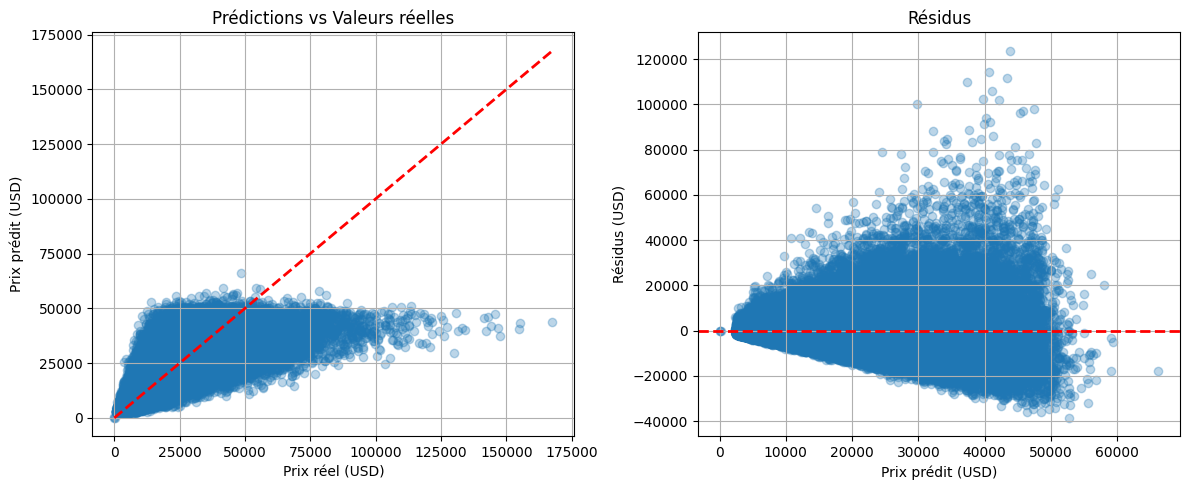

In [39]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Prix réel (USD)")
plt.ylabel("Prix prédit (USD)")
plt.title("Prédictions vs Valeurs réelles")
plt.grid(True)

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel("Prix prédit (USD)")
plt.ylabel("Résidus (USD)")
plt.title("Résidus")
plt.grid(True)

plt.tight_layout()
plt.show()

In [40]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
rf_model = pipeline.named_steps["model"]
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop 20 features les plus importantes:")
print(importance_df.head(20))


Top 20 features les plus importantes:
                     feature  importance
1                 mileage_km    0.877974
2                 horsepower    0.024095
4             days_on_market    0.023811
3            condition_score    0.019994
0                       year    0.012187
66        fuel_type_Gasoline    0.002555
64               country_USA    0.002324
62           country_Germany    0.002003
69       transmission_Manual    0.001955
67          fuel_type_Hybrid    0.001612
63                country_UK    0.001553
65        fuel_type_Electric    0.001458
55            model_Sportage    0.000608
22               model_F-150    0.000593
10              model_Altima    0.000587
58              model_Tucson    0.000587
45                  model_Q5    0.000567
68  fuel_type_Plug-in Hybrid    0.000566
30             model_Impreza    0.000562
13                model_CX-5    0.000559


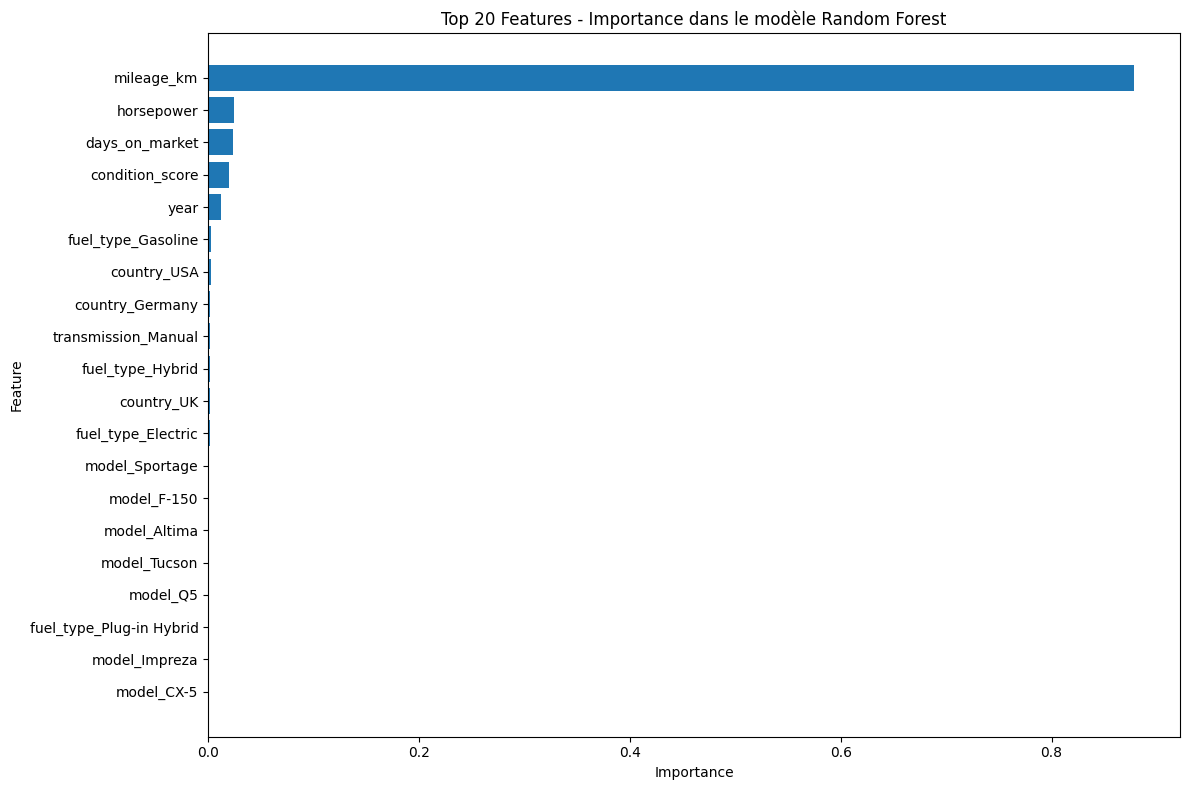

In [41]:
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
plt.barh(range(len(top_features)), top_features["importance"])
plt.yticks(range(len(top_features)), top_features["feature"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Importance dans le modèle Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [42]:
imputer_num = pipeline.named_steps["preprocess"].named_transformers_["num"].named_steps["imputer"]
imputer_cat = pipeline.named_steps["preprocess"].named_transformers_["cat"].named_steps["imputer"]

print("Valeurs médianes utilisées pour l'imputation (features numériques):")
print(dict(zip(num_features, imputer_num.statistics_)))

print("\nValeurs les plus fréquentes utilisées pour l'imputation (features catégorielles):")
print(dict(zip(cat_features, imputer_cat.statistics_)))

Valeurs médianes utilisées pour l'imputation (features numériques):
{'year': np.float64(2014.0), 'mileage_km': np.float64(164554.0), 'horsepower': np.float64(370.0), 'condition_score': np.float64(6.9), 'days_on_market': np.float64(183.0)}

Valeurs les plus fréquentes utilisées pour l'imputation (features catégorielles):
{'model': 'S-Class', 'country': 'USA', 'fuel_type': 'Gasoline', 'transmission': 'Automatic'}


In [43]:
model_filename = "random_forest_cars.pkl"
joblib.dump(pipeline, model_filename)
print(f"Modèle sauvegardé: {model_filename}")

Modèle sauvegardé: random_forest_cars.pkl


In [44]:
loaded_model = joblib.load(model_filename)
y_pred_loaded = loaded_model.predict(X_test)

print("Test du modèle chargé:")
print(f"R² (modèle chargé): {r2_score(y_test, y_pred_loaded):.4f}")
print("Le modèle a été chargé avec succès!")

Test du modèle chargé:
R² (modèle chargé): 0.6638
Le modèle a été chargé avec succès!


In [45]:
example = X_test.iloc[0:5]
predictions = pipeline.predict(example)

print("Exemples de prédictions:")
print("=" * 70)
for i in range(len(example)):
    real_price = y_test.iloc[i]
    pred_price = predictions[i]
    diff = pred_price - real_price
    diff_pct = (diff / real_price) * 100
    
    print(f"\nVéhicule {i+1}:")
    print(f"  Prix réel:    {real_price:,.2f} USD")
    print(f"  Prix prédit:  {pred_price:,.2f} USD")
    print(f"  Différence:   {diff:,.2f} USD ({diff_pct:+.2f}%)")
print("=" * 70)

Exemples de prédictions:

Véhicule 1:
  Prix réel:    17,551.00 USD
  Prix prédit:  25,563.12 USD
  Différence:   8,012.12 USD (+45.65%)

Véhicule 2:
  Prix réel:    13,662.00 USD
  Prix prédit:  19,606.14 USD
  Différence:   5,944.14 USD (+43.51%)

Véhicule 3:
  Prix réel:    28,406.00 USD
  Prix prédit:  26,743.90 USD
  Différence:   -1,662.10 USD (-5.85%)

Véhicule 4:
  Prix réel:    9,185.00 USD
  Prix prédit:  9,012.01 USD
  Différence:   -172.99 USD (-1.88%)

Véhicule 5:
  Prix réel:    37,289.00 USD
  Prix prédit:  26,549.85 USD
  Différence:   -10,739.15 USD (-28.80%)


In [46]:
from sklearn.tree import export_text

feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
tree = pipeline.named_steps["model"].estimators_[0]

print("Structure du premier arbre (profondeur max = 3):")
print("=" * 70)
print(export_text(tree, feature_names=list(feature_names), max_depth=3))

Structure du premier arbre (profondeur max = 3):
|--- mileage_km <= -0.67
|   |--- mileage_km <= -1.37
|   |   |--- mileage_km <= -1.69
|   |   |   |--- mileage_km <= -1.86
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- mileage_km >  -1.86
|   |   |   |   |--- truncated branch of depth 17
|   |   |--- mileage_km >  -1.69
|   |   |   |--- mileage_km <= -1.53
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- mileage_km >  -1.53
|   |   |   |   |--- truncated branch of depth 17
|   |--- mileage_km >  -1.37
|   |   |--- mileage_km <= -1.03
|   |   |   |--- year <= 0.96
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- year >  0.96
|   |   |   |   |--- truncated branch of depth 17
|   |   |--- mileage_km >  -1.03
|   |   |   |--- mileage_km <= -0.82
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- mileage_km >  -0.82
|   |   |   |   |--- truncated branch of depth 17
|--- mileage_km >  -0.67
|   |--- mileage_km <= 0.22
|